In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

# Load master dataset
df = pd.read_csv('../data/master_hr_dataset.csv')

print(f"Shape: {df.shape}")
print(f"\nAttrition distribution:\n{df['Attrition'].value_counts()}")
print(f"\nAttrition rate: {(df['Attrition'] == 'Yes').mean():.1%}")

Shape: (1470, 40)

Attrition distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate: 16.1%


In [2]:
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "No missing values ✅")

print("\n=== NUMERIC SUMMARY ===")
df.describe().round(2)

=== DATA TYPES ===
Age                           int64
Attrition                    object
BusinessTravel               object
DailyRate                     int64
Department                   object
DistanceFromHome              int64
Education                     int64
EducationField               object
EmployeeNumber                int64
EnvironmentSatisfaction       int64
Gender                       object
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                      object
JobSatisfaction               int64
MaritalStatus                object
MonthlyIncome                 int64
MonthlyRate                   int64
NumCompaniesWorked            int64
OverTime                     object
PercentSalaryHike             int64
PerformanceRating             int64
RelationshipSatisfaction      int64
StockOptionLevel              int64
TotalWorkingYears             int64
TrainingTimesLastYear         int64
WorkLifeB

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,EngagementSurvey,EmpSatisfaction,DaysLateLast30,Absences,BurnRate,MentalFatigueScore,WFHAvailable,ResourceAllocation
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.0,1470.00
mean,36.92,802.49,9.19,2.91,1024.87,2.72,65.89,2.73,2.06,2.73,6502.93,14313.10,2.69,15.21,3.15,2.71,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12,4.19,3.99,0.0,10.56,0.43,5.64,0.8,4.01
std,9.14,403.51,8.11,1.02,602.02,1.09,20.33,0.71,1.11,1.10,4707.96,7117.79,2.50,3.66,0.36,1.08,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57,0.19,0.12,0.0,1.43,0.15,1.30,0.4,1.97
min,18.00,102.00,1.00,1.00,1.00,1.00,30.00,1.00,1.00,1.00,1009.00,2094.00,0.00,11.00,3.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,3.82,3.00,0.0,6.00,0.27,4.20,0.0,2.00
25%,30.00,465.00,2.00,2.00,491.25,2.00,48.00,2.00,1.00,2.00,2911.00,8047.00,1.00,12.00,3.00,2.00,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00,4.22,4.00,0.0,10.00,0.28,4.30,1.0,2.00
50%,36.00,802.00,7.00,3.00,1020.50,3.00,66.00,3.00,2.00,3.00,4919.00,14235.50,2.00,14.00,3.00,3.00,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00,4.28,4.00,0.0,10.00,0.42,5.60,1.0,4.00
75%,43.00,1157.00,14.00,4.00,1555.75,4.00,83.75,3.00,3.00,4.00,8379.00,20461.50,4.00,18.00,3.00,4.00,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00,4.30,4.00,0.0,10.50,0.50,6.30,1.0,6.00
max,60.00,1499.00,29.00,5.00,2068.00,4.00,100.00,4.00,5.00,4.00,19999.00,26999.00,9.00,25.00,4.00,4.00,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00,4.83,4.00,0.0,14.00,0.86,9.00,1.0,9.00


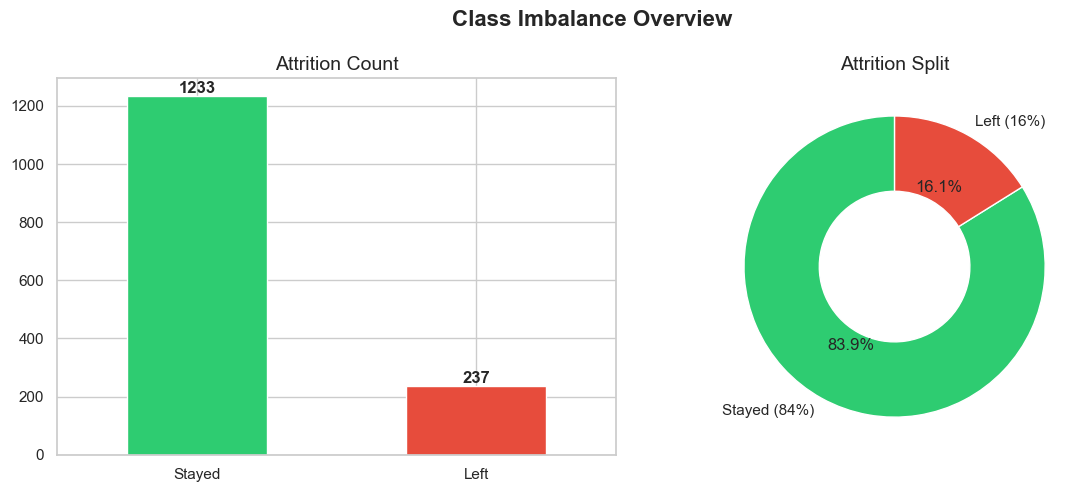

✅ Saved


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
colors = ['#2ecc71', '#e74c3c']
df['Attrition'].value_counts().plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='white', width=0.5
)
axes[0].set_title('Attrition Count', fontsize=14)
axes[0].set_xlabel('')
axes[0].set_xticklabels(['Stayed', 'Left'], rotation=0)
for i, v in enumerate(df['Attrition'].value_counts()):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Percentage donut
sizes = df['Attrition'].value_counts()
axes[1].pie(
    sizes, labels=['Stayed (84%)', 'Left (16%)'],
    colors=colors, autopct='%1.1f%%',
    startangle=90, wedgeprops={'width': 0.5}
)
axes[1].set_title('Attrition Split', fontsize=14)

plt.suptitle('Class Imbalance Overview', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/eda_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved")

C:\Users\aniru\AppData\Local\Temp\ipykernel_15032\2576392661.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dept_rate, x='Department', y='AttritionRate',
C:\Users\aniru\AppData\Local\Temp\ipykernel_15032\2576392661.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=role_rate, x='AttritionRate', y='JobRole',


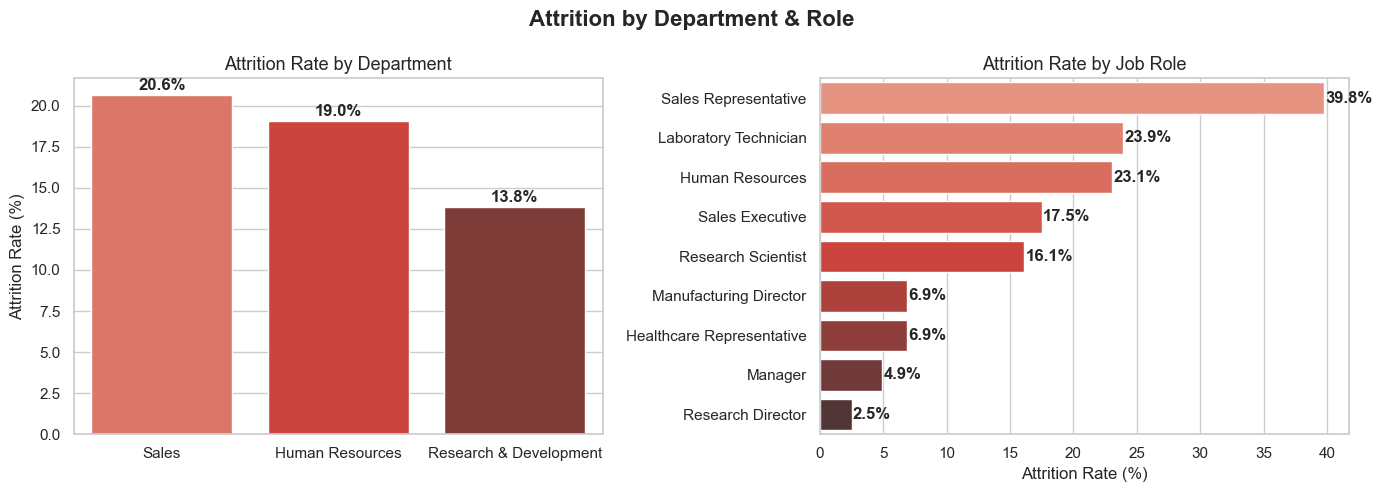

✅ Saved


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By Department
dept_rate = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).sort_values(ascending=False).reset_index()
dept_rate.columns = ['Department', 'AttritionRate']

sns.barplot(data=dept_rate, x='Department', y='AttritionRate',
            palette='Reds_d', ax=axes[0])
axes[0].set_title('Attrition Rate by Department', fontsize=13)
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_xlabel('')
for i, row in dept_rate.iterrows():
    axes[0].text(i, row['AttritionRate'] + 0.3,
                 f"{row['AttritionRate']:.1f}%", ha='center', fontweight='bold')

# By Job Role
role_rate = df.groupby('JobRole')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).sort_values(ascending=False).reset_index()
role_rate.columns = ['JobRole', 'AttritionRate']

sns.barplot(data=role_rate, x='AttritionRate', y='JobRole',
            palette='Reds_d', ax=axes[1])
axes[1].set_title('Attrition Rate by Job Role', fontsize=13)
axes[1].set_xlabel('Attrition Rate (%)')
axes[1].set_ylabel('')
for i, row in role_rate.iterrows():
    axes[1].text(row['AttritionRate'] + 0.1, i,
                 f"{row['AttritionRate']:.1f}%", va='center', fontweight='bold')

plt.suptitle('Attrition by Department & Role', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/eda_dept_role.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved")

C:\Users\aniru\AppData\Local\Temp\ipykernel_15032\4244466345.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=overtime_rate, x='OverTime', y='AttritionRate',
C:\Users\aniru\AppData\Local\Temp\ipykernel_15032\4244466345.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sat_rate, x='JobSatisfaction', y='AttritionRate',
C:\Users\aniru\AppData\Local\Temp\ipykernel_15032\4244466345.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=burn_rate, x='BurnRateBin', y='AttritionRate',


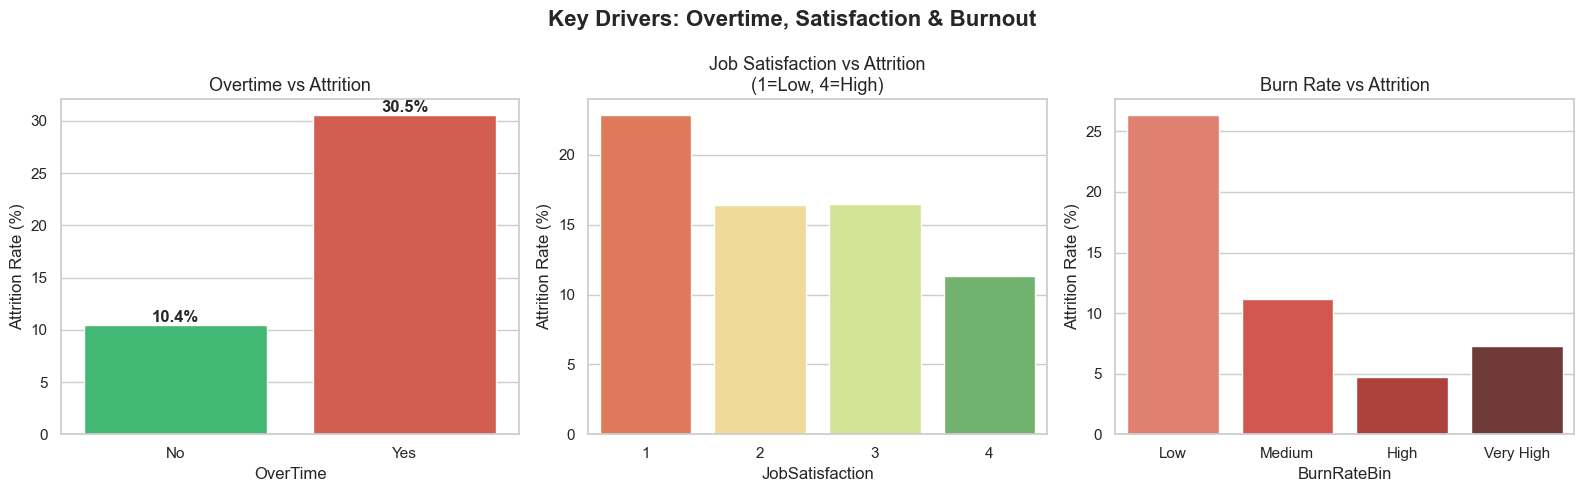

✅ Saved


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overtime vs Attrition
overtime_rate = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
overtime_rate.columns = ['OverTime', 'AttritionRate']

sns.barplot(data=overtime_rate, x='OverTime', y='AttritionRate',
            palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Overtime vs Attrition', fontsize=13)
axes[0].set_ylabel('Attrition Rate (%)')
for i, row in overtime_rate.iterrows():
    axes[0].text(i, row['AttritionRate'] + 0.3,
                 f"{row['AttritionRate']:.1f}%", ha='center', fontweight='bold')

# Job Satisfaction vs Attrition
sat_rate = df.groupby('JobSatisfaction')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
sat_rate.columns = ['JobSatisfaction', 'AttritionRate']

sns.barplot(data=sat_rate, x='JobSatisfaction', y='AttritionRate',
            palette='RdYlGn', ax=axes[1])
axes[1].set_title('Job Satisfaction vs Attrition\n(1=Low, 4=High)', fontsize=13)
axes[1].set_ylabel('Attrition Rate (%)')

# Burn Rate vs Attrition
df['BurnRateBin'] = pd.cut(df['BurnRate'], bins=4,
                            labels=['Low', 'Medium', 'High', 'Very High'])
burn_rate = df.groupby('BurnRateBin', observed=True)['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
burn_rate.columns = ['BurnRateBin', 'AttritionRate']

sns.barplot(data=burn_rate, x='BurnRateBin', y='AttritionRate',
            palette='Reds_d', ax=axes[2])
axes[2].set_title('Burn Rate vs Attrition', fontsize=13)
axes[2].set_ylabel('Attrition Rate (%)')

plt.suptitle('Key Drivers: Overtime, Satisfaction & Burnout', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/eda_key_drivers.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved")

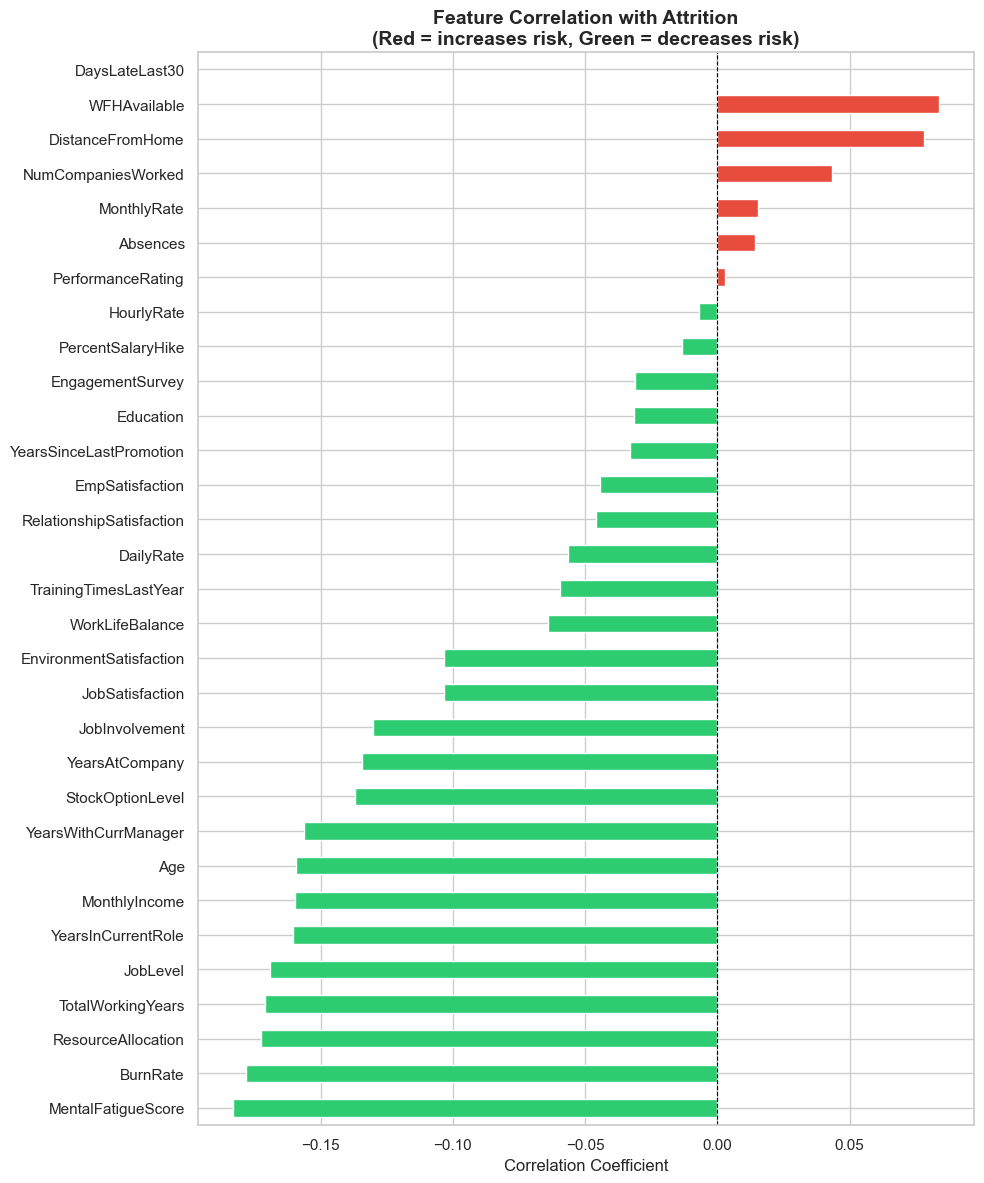

✅ Saved


In [6]:
# Convert attrition to binary for correlation
df['Attrition_bin'] = (df['Attrition'] == 'Yes').astype(int)

# Select numeric columns only
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in
                ['Attrition_bin', 'EmployeeNumber']]

# Compute correlations with attrition
corr = df[numeric_cols + ['Attrition_bin']].corr()['Attrition_bin']
corr = corr.drop('Attrition_bin').sort_values()

# Plot
fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr]
corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Feature Correlation with Attrition\n(Red = increases risk, Green = decreases risk)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')

plt.tight_layout()
plt.savefig('../models/eda_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved")

In [7]:
enriched_cols = [
    'EngagementSurvey', 'EmpSatisfaction', 'DaysLateLast30',
    'Absences', 'BurnRate', 'MentalFatigueScore',
    'WFHAvailable', 'ResourceAllocation'
]

# Compare means for stayed vs left
summary = df.groupby('Attrition')[enriched_cols].mean().round(3).T
summary.columns = ['Stayed', 'Left']
summary['Difference'] = (summary['Left'] - summary['Stayed']).round(3)
summary['Signal'] = summary['Difference'].apply(
    lambda x: '🔴 Higher when left' if x > 0.05
    else ('🟢 Lower when left' if x < -0.05 else '⚪ Weak signal')
)

print("=== ENRICHED COLUMNS: Stayed vs Left ===")
print(summary.to_string())

=== ENRICHED COLUMNS: Stayed vs Left ===
                    Stayed    Left  Difference              Signal
EngagementSurvey     4.197   4.181      -0.016       ⚪ Weak signal
EmpSatisfaction      3.989   3.975      -0.014       ⚪ Weak signal
DaysLateLast30       0.000   0.000       0.000       ⚪ Weak signal
Absences            10.551  10.605       0.054  🔴 Higher when left
BurnRate             0.445   0.371      -0.074   🟢 Lower when left
MentalFatigueScore   5.749   5.102      -0.647   🟢 Lower when left
WFHAvailable         0.782   0.873       0.091  🔴 Higher when left
ResourceAllocation   4.158   3.232      -0.926   🟢 Lower when left
